In [1]:
]activate ../../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`

In [3]:
using Revise
includet("./base.jl")

In [5]:
using GLMakie
using CairoMakie
CairoMakie.activate!()

# Generate systems, solve ODE, filter and test

In [27]:
K = 10.
l = 0.999
T = 1e8
tol = 1e-9
df = solve_si_odes("test1.jld2", 500,
    K, l,
    T, tol,
);
count(df.good), nrow(df)

Progress: 100%|█████████████████████████████████████████| Time: 0:04:13

(336, 500)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:03

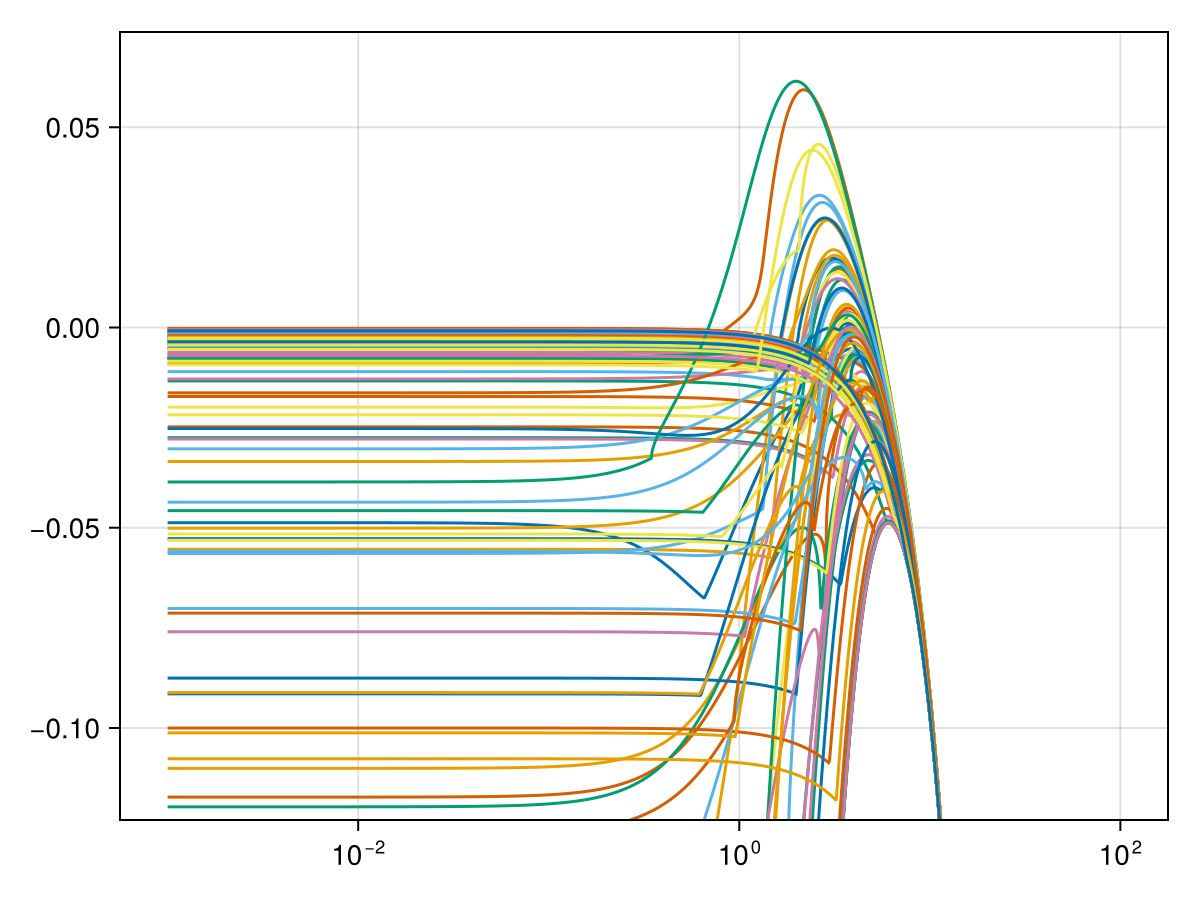

In [9]:
ks = 10 .^ range(-3, 2, 1000)
DN = 1e-3
p = 1e0
(; Ds, mrls) = si_disprels(df, ks, DN, 1., p);

fig = Figure()
ax = Axis(fig[1,1]; xscale=log10)

for i in 1:nrow(df)
    if df.good[i]
        lines!(ks, mrls[i])
    end
end

mm = abs(maximum(maximum.(mrls[df.good])))
# xlims!(ax, 1e0, 1e2)
ylims!(ax, (-2., 1.2) .* mm)

fig

# Disprels ps, find a sensible system size and prep for PDE runs

In [33]:
num_systems = 100

# disprels and peak finding
ks = 10 .^ range(-2, 2, 1000)  # grid the peak k gets read off, no root finding
ps = 10 .^ range(-2, 0, 5)          # byproduct diffusions (DR) to compare each system at
DN = 1e-3                      # strain diffusion
DI = 1.0                       # influx resource diffusion

# system size and spatial u0
num_peaks = 1    # peaks each domain fits; L is set per (system, p) from its own peak k
sN = 250         # spatial gridpoints, same for every run so dx varies with L
epsilon = 1e-3   # uniform +/- perturbation added to the ODE steady state
seed = 1         # so the u0s can be regenerated
T = T            # PDE end time, same as the ODE T in the section above

out_fname = "systems.jld2"

"systems.jld2"

In [34]:
gdf = df[df.good, :]
gdf.df_row = findall(df.good) # which df row each one was, survives later filtering

(; mrls, peak_ks, peak_hs, at_edge) = disprel_peak_ks(gdf, ks, DN, DI, ps)

# peaks on the edge of the ks range are not real peaks - widen ks if any turn up
count(at_edge), count(ismissing, peak_ks), length(peak_ks)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:02

(0, 660, 1680)

In [35]:
# Drop anything that is not spatially unstable at *every* p. `good` only says the
# well-mixed steady state is stable (that is the k=0 Jacobian), so a good system
# can still have no k>0 instability, and then there is no peak to size a domain
# to. Cutting them here means nothing downstream has to deal with missings.
keep = findall([all(!ismissing, peak_ks[i, :]) for i in 1:nrow(gdf)])
@show length(keep), nrow(gdf)
if !isnothing(num_systems)
    keep = keep[sample(1:length(keep), num_systems; replace=false)]
end;

gdf = gdf[keep, :]
mrls = mrls[keep, :]
peak_ks = disallowmissing(peak_ks[keep, :])
peak_hs = disallowmissing(peak_hs[keep, :])
at_edge = at_edge[keep, :]
nrow(gdf)

(length(keep), nrow(gdf)) = (109, 336)

100

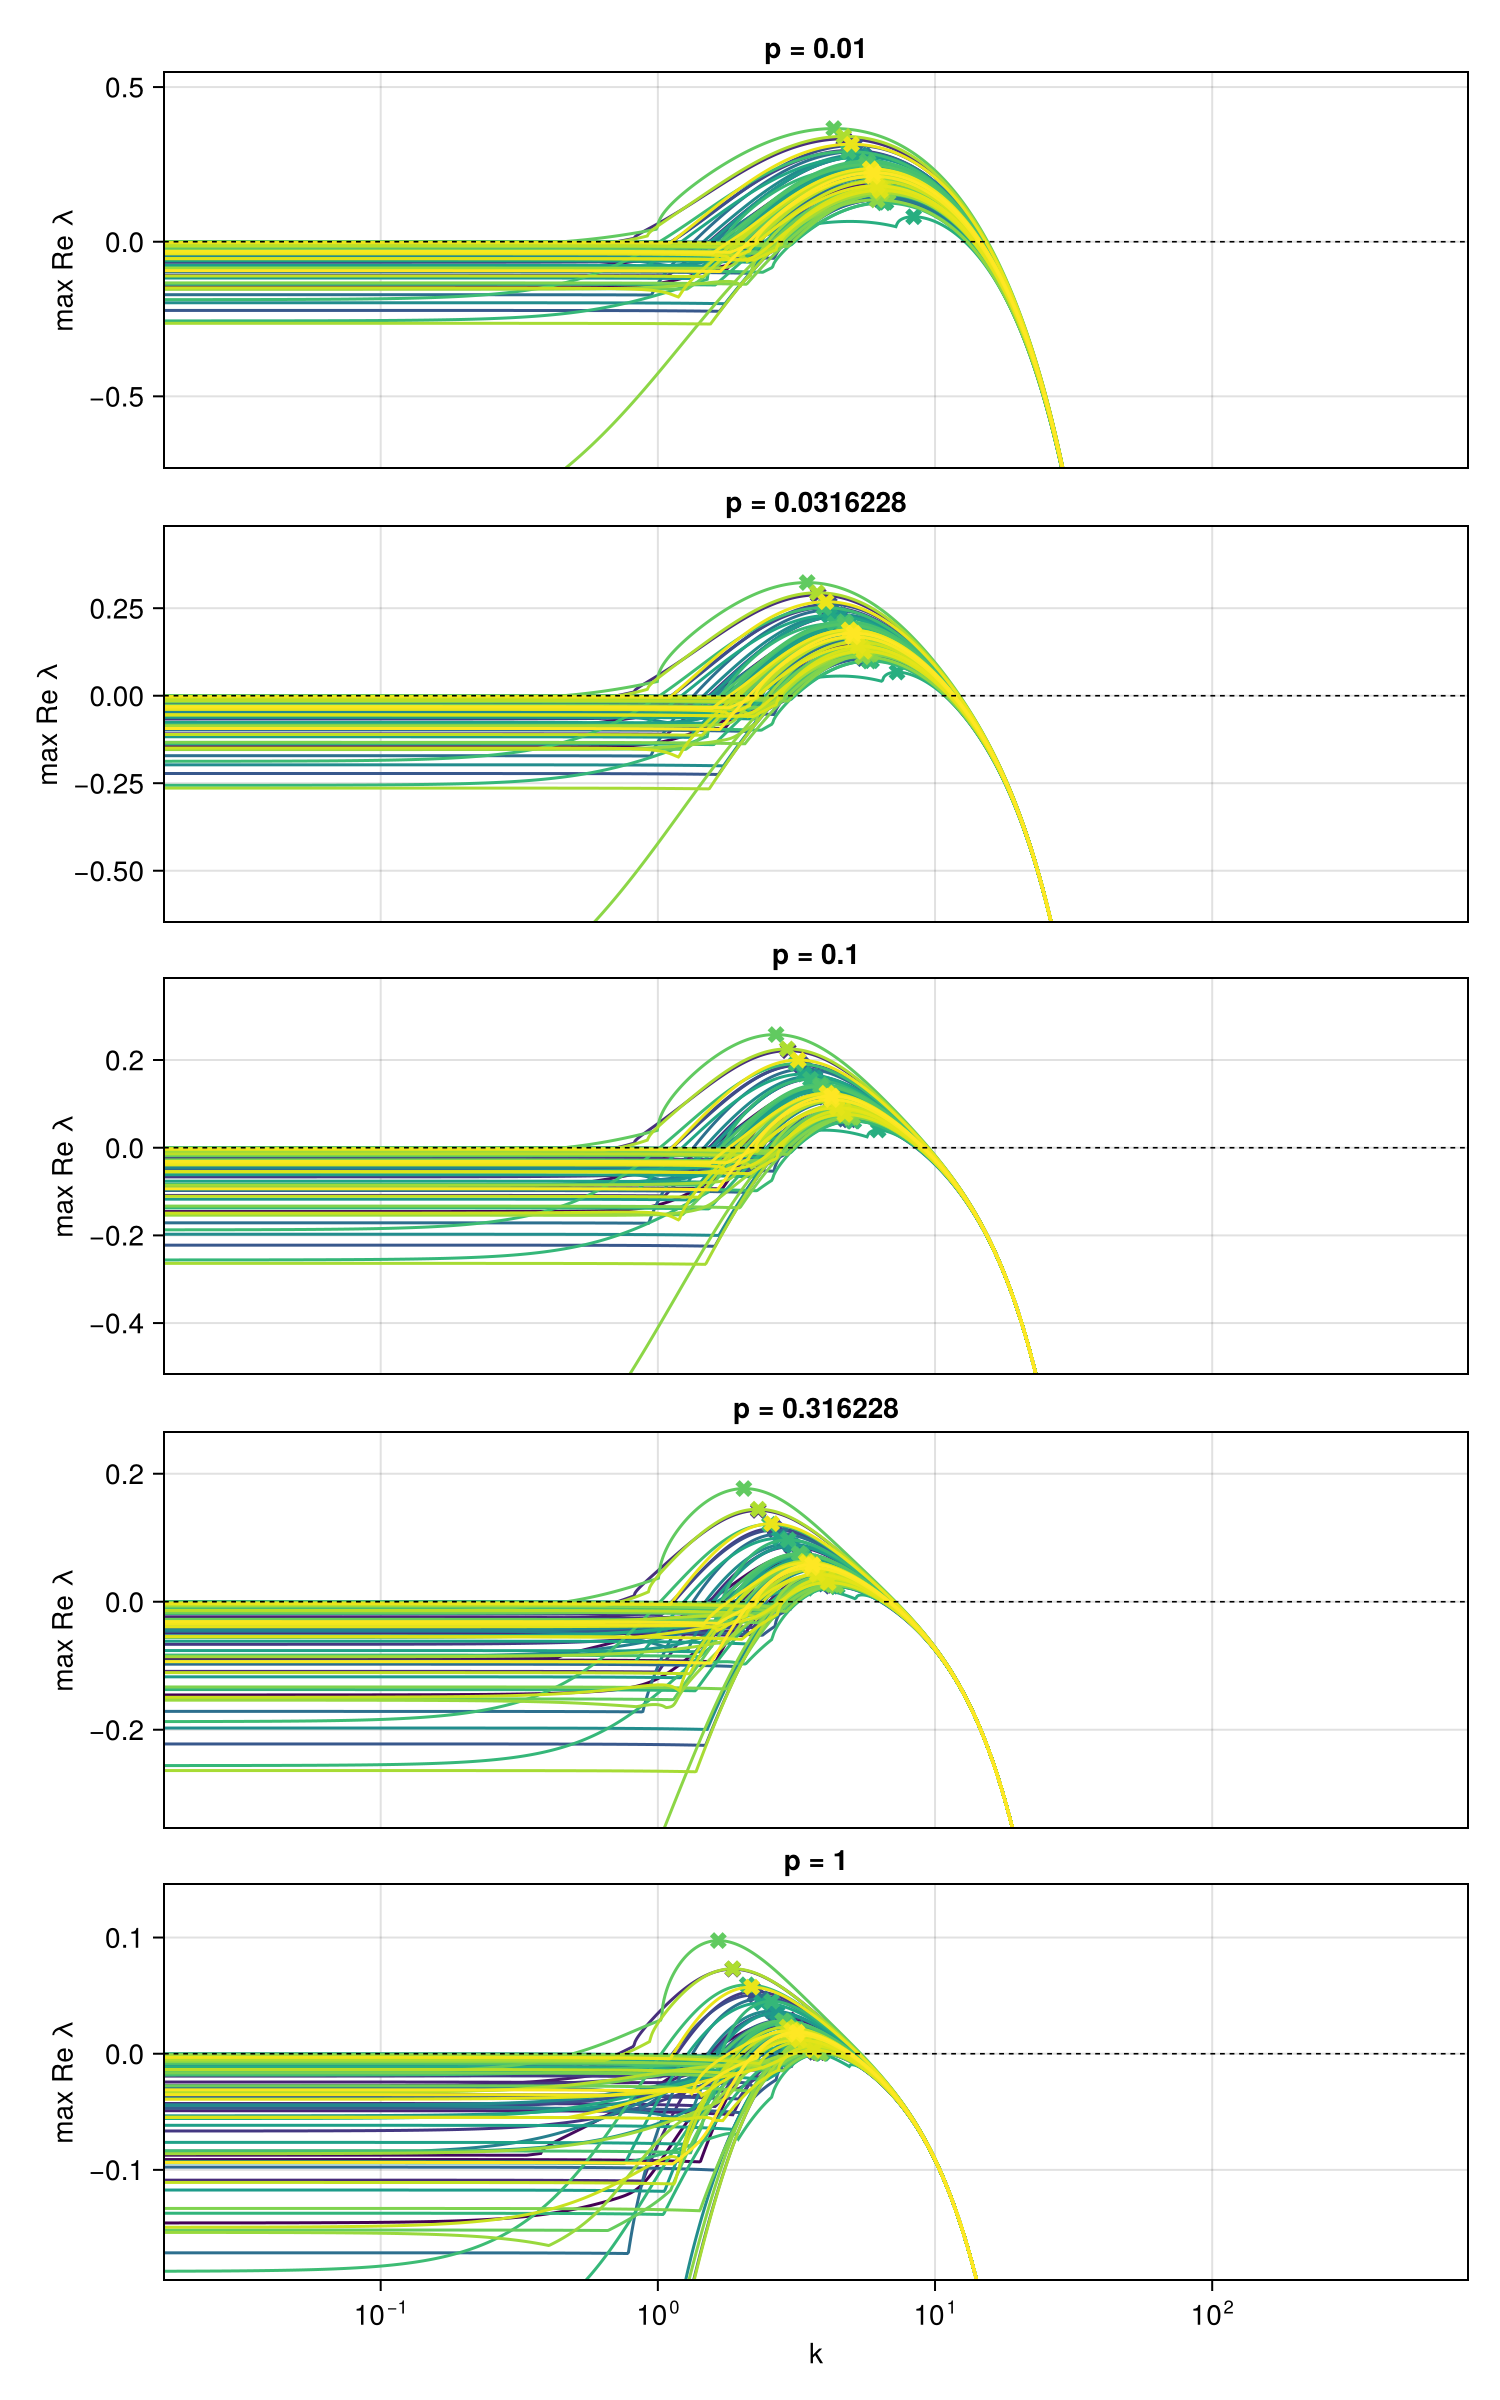

In [36]:
colors = Makie.resample_cmap(:viridis, max(nrow(gdf), 2))

fig = Figure(; size=(750, 240 * length(ps)))
axs = map(eachindex(ps)) do j
    Axis(fig[j, 1]; xscale=log10, ylabel="max Re λ", title=@sprintf("p = %g", ps[j]))
end
axs[end].xlabel = "k"

for j in eachindex(ps)
    for i in 1:nrow(gdf)
        lines!(axs[j], ks, mrls[i, j]; color=colors[i])
        scatter!(axs[j], [peak_ks[i, j]], [peak_hs[i, j]];
            color=colors[i], marker=:xcross, markersize=12)
    end
    hlines!(axs[j], 0.0; color=:black, linestyle=:dash, linewidth=0.8)
    mm = maximum(peak_hs[:, j]) # scale each panel by its own tallest peak
    ylims!(axs[j], -2mm, 1.5mm)
end

linkxaxes!(axs...)
# zoom onto where the peaks actually are rather than the whole scanned range
pkext = extrema(peak_ks)
# on all of them, not just the linked one - an axis left on autolimits pulls the
# whole link back out to the full ks range
xlims!.(axs, pkext[1] / 100, pkext[2] * 100)
hidexdecorations!.(axs[1:end-1]; grid=false)
rowgap!(fig.layout, 8)

fig

In [37]:
# One L per (system, p), each sized to fit exactly num_peaks peaks of that
# system's peak k at that p. Every run therefore starts with the same peak count
# and, since sN is shared, the same resolution per peak - only L differs.
Ls = choose_L.(peak_ks, num_peaks)

sizes_df = DataFrame(; df_row=gdf.df_row)
for j in eachindex(ps)
    sizes_df[!, @sprintf("k_p%g", ps[j])] = peak_ks[:, j]
    sizes_df[!, @sprintf("L_p%g", ps[j])] = Ls[:, j]
end
sizes_df

Row,df_row,k_p0.01,L_p0.01,k_p0.0316228,L_p0.0316228,k_p0.1,L_p0.1,k_p0.316228,L_p0.316228,k_p1,L_p1
,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,208,5.73798,1.09502,4.81596,1.30466,3.96825,1.58337,3.36145,1.86919,2.98177,2.1072
2,83,6.00868,1.04569,5.08987,1.23445,4.27199,1.47079,3.61875,1.73629,3.21001,1.95737
3,392,6.71161,0.936166,5.79112,1.08497,4.95102,1.26907,4.31156,1.45729,3.78947,1.65806
4,53,5.68532,1.10516,4.77176,1.31674,3.89575,1.61283,3.23974,1.93941,2.79542,2.24767
5,449,6.46861,0.971335,5.58145,1.12573,4.72797,1.32894,4.11732,1.52604,3.61875,1.73629
6,161,6.46861,0.971335,5.63314,1.1154,4.77176,1.31674,4.15546,1.51203,3.61875,1.73629
7,277,5.53022,1.13615,4.68458,1.34125,3.89575,1.61283,3.3306,1.8865,2.95441,2.12672
8,1,6.00868,1.04569,5.08987,1.23445,4.23279,1.48441,3.58554,1.75237,3.18055,1.9755
9,464,5.53022,1.13615,4.81596,1.30466,4.005,1.56883,3.39258,1.85204,2.98177,2.1072


In [38]:
Random.seed!(seed)

# One u0 per system, shared by all of its p runs: the p comparison should not be
# confounded by each run starting from a different random perturbation. It only
# depends on sN and the ODE steady state, so the differing Ls do not enter here.
u0s = map(1:nrow(gdf)) do i
    Ns, Nr = get_Ns(gdf.params[i])
    u0 = perturb_u0_uniform(Ns, Nr, expand_u0_to_size((sN,), gdf.final_states[i]), epsilon)
    clamp.(u0, 0., Inf)
end

@show length(u0s) size(u0s[1])
extrema(Ls ./ sN) # dx range

length(u0s) = 100
size(u0s[1]) = (40, 250)

(0.003001352028240823, 0.015206233025128892)

In [40]:
# One row per (system, p) - everything a PDE run needs bar the tolerances and
# maxtime, which are left to whoever runs it.
sysjs = [(i, j) for i in 1:nrow(gdf) for j in eachindex(ps)]

pde_df = DataFrame(;
    gdf_row=[i for (i, _) in sysjs],             # index into gdf / u0s
    df_row=[gdf.df_row[i] for (i, _) in sysjs],  # index into the original df
    p=[ps[j] for (_, j) in sysjs],
    params=[gdf.params[i] for (i, _) in sysjs],
    Ds=[make_si_Ds(gdf.params[i], DN, DI, ps[j]) for (i, j) in sysjs],
    L=[Ls[i, j] for (i, j) in sysjs],  # sized to num_peaks peaks of this (system, p)
    sN=fill(sN, length(sysjs)),
    T=fill(T, length(sysjs)),
    u0=[u0s[i] for (i, _) in sysjs],  # same array object across a system's ps
    mrls=[mrls[i, j] for (i, j) in sysjs],  # disprel on metadata.ks, handy to look at
)

metadata = (; K, l, ks, ps, DN, DI, num_peaks, sN, epsilon, seed)
jldsave(out_fname; metadata, pde_df)

@show nrow(pde_df) filesize(out_fname) / 1e6
select(pde_df, Not(:params, :Ds, :u0, :mrls)) # the big columns just spam the output

nrow(pde_df) = 500
filesize(out_fname) / 1.0e6 = 19.609937

Row,gdf_row,df_row,p,L,sN,T
,Int64,Int64,Float64,Float64,Int64,Float64
1,1,208,0.01,1.09502,250,1.0e8
2,1,208,0.0316228,1.30466,250,1.0e8
3,1,208,0.1,1.58337,250,1.0e8
4,1,208,0.316228,1.86919,250,1.0e8
5,1,208,1.0,2.1072,250,1.0e8
6,2,83,0.01,1.04569,250,1.0e8
7,2,83,0.0316228,1.23445,250,1.0e8
8,2,83,0.1,1.47079,250,1.0e8
9,2,83,0.316228,1.73629,250,1.0e8
